In [ ]:
import os, ast, warnings, json, joblib, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu, wilcoxon
from scikit_posthocs import posthoc_dunn
from scipy.stats import kruskal
import itertools
from sklearn.model_selection import (
    StratifiedKFold, GroupKFold, GroupShuffleSplit, StratifiedShuffleSplit
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
delta_emb_df = pd.read_json('AF2_data_with_emb_l1_l2_average.json', lines=True)
data = '../alphafold/AF2_disorder_all_features.csv'
dbnsfp_data = '../dbNSFP/dbNSFP4.8a_variant.disorder_genes.tsv'


In [ ]:
labels    = delta_emb_df['Class']
y_encoded = (labels == 'Deleterious').astype(int).values
genes     = delta_emb_df['GENES'].values

In [ ]:
def select_embedding_features(X_train_emb, y_train, target_dim=20):
    """Fit F-statistic selector on training data only. Returns selector."""
    sel = SelectKBest(f_classif, k=min(target_dim, X_train_emb.shape[1]))
    sel.fit(X_train_emb, y_train)
    return sel
 
 
def apply_selection(X_df, sel, emb_pattern):
    """Apply a fitted selector to a DataFrame. Returns reduced DataFrame."""
    emb_cols     = [c for c in X_df.columns if emb_pattern in c and '_value_' in c]
    non_emb_cols = [c for c in X_df.columns if c not in emb_cols]
    selected     = sel.get_support(indices=True)
    sel_cols     = [emb_cols[i] for i in selected]
    return X_df[non_emb_cols + sel_cols]
 
 
 
def _run_cv_gene(model_factory, X_df, y, genes, method, model_name,
                 n_splits=10, random_state=42, emb_pattern=None, target_dim=20):
    """Gene-stratified CV. Feature selection + scaling inside each fold."""
    gkf = GroupKFold(n_splits=n_splits)
    records = []
    for fold, (tr, va) in enumerate(gkf.split(X_df, y, groups=genes)):
        X_tr_raw, X_va_raw = X_df.iloc[tr], X_df.iloc[va]
        y_tr,     y_va     = y[tr], y[va]
 
        # Feature selection on training fold
        if emb_pattern:
            emb_cols = [c for c in X_tr_raw.columns if emb_pattern in c and '_value_' in c]
            if emb_cols:
                sel = select_embedding_features(
                    X_tr_raw[emb_cols].values, y_tr, target_dim
                )
                X_tr_raw = apply_selection(X_tr_raw, sel, emb_pattern)
                X_va_raw = apply_selection(X_va_raw, sel, emb_pattern)
 
        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_tr_raw.apply(pd.to_numeric, errors='coerce'))
        X_va_sc  = scaler.transform(X_va_raw.apply(pd.to_numeric, errors='coerce'))
 
        model = model_factory()
        model.fit(X_tr_sc, y_tr)
        y_prob = model.predict_proba(X_va_sc)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
 
        records.append({
            'fold':       fold,
            'roc_auc':    roc_auc_score(y_va, y_prob),
            'auc_pr':     average_precision_score(y_va, y_prob),
            'accuracy':   accuracy_score(y_va, y_pred),
            'method':     method,
            'model_name': model_name,
            'cv_type':    'random',
        })
    return pd.DataFrame(records)
 
 
def _run_cv_random(model_factory, X_df, y, method, model_name,
                   n_splits=10, random_state=42, emb_pattern=None, target_dim=20):
    """Random stratified CV. Feature selection + scaling inside each fold."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    records = []
    for fold, (tr, va) in enumerate(skf.split(X_df, y)):
        X_tr_raw, X_va_raw = X_df.iloc[tr], X_df.iloc[va]
        y_tr,     y_va     = y[tr], y[va]
 
        if emb_pattern:
            emb_cols = [c for c in X_tr_raw.columns if emb_pattern in c and '_value_' in c]
            if emb_cols:
                sel = select_embedding_features(
                    X_tr_raw[emb_cols].values, y_tr, target_dim
                )
                X_tr_raw = apply_selection(X_tr_raw, sel, emb_pattern)
                X_va_raw = apply_selection(X_va_raw, sel, emb_pattern)
 
        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_tr_raw.apply(pd.to_numeric, errors='coerce'))
        X_va_sc  = scaler.transform(X_va_raw.apply(pd.to_numeric, errors='coerce'))
 
        model = model_factory()
        model.fit(X_tr_sc, y_tr)
        y_prob = model.predict_proba(X_va_sc)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
 
        records.append({
            'fold':       fold,
            'roc_auc':    roc_auc_score(y_va, y_prob),
            'auc_pr':     average_precision_score(y_va, y_prob),
            'accuracy':   accuracy_score(y_va, y_pred),
            'method':     method,
            'model_name': model_name,
            'cv_type':    'gene',
        })
    return pd.DataFrame(records)
 
 
def run_both_cv(model_factory, X_df, y, genes, method, model_name,
                n_splits=10, random_state=42, emb_pattern=None, target_dim=20):
    """Run both gene-stratified and random CV. Returns combined DataFrame."""
    gene_df   = _run_cv_gene(model_factory, X_df, y, genes, method, model_name,
                              n_splits, random_state, emb_pattern, target_dim)
    random_df = _run_cv_random(model_factory, X_df, y, method, model_name,
                                n_splits, random_state, emb_pattern, target_dim)
    return pd.concat([gene_df, random_df], ignore_index=True)
 
 
# Public wrappers matching original function signatures
 
def train_xgboost_with_cv(X, y, method, model_name, genes=None,
                           n_splits=10, random_state=42, emb_pattern=None):
    factory = lambda: XGBClassifier(
        eval_metric='logloss', tree_method='hist', device='cuda',
        random_state=random_state
    )
    if genes is not None:
        return run_both_cv(factory, X, y, genes, method, model_name,
                           n_splits, random_state, emb_pattern)
    return _run_cv_random(factory, X, y, method, model_name,
                          n_splits, random_state, emb_pattern)
 
 
def train_random_forest_with_cv(X, y, method, model_name, genes=None,
                                 n_splits=10, random_state=42, emb_pattern=None):
    factory = lambda: RandomForestClassifier(
        class_weight='balanced', random_state=random_state
    )
    if genes is not None:
        return run_both_cv(factory, X, y, genes, method, model_name,
                           n_splits, random_state, emb_pattern)
    return _run_cv_random(factory, X, y, method, model_name,
                          n_splits, random_state, emb_pattern)
 
 
def train_naive_bayes_with_cv(X, y, method, model_name, genes=None,
                               n_splits=10, random_state=42, emb_pattern=None):
    factory = lambda: GaussianNB()
    if genes is not None:
        return run_both_cv(factory, X, y, genes, method, model_name,
                           n_splits, random_state, emb_pattern)
    return _run_cv_random(factory, X, y, method, model_name,
                          n_splits, random_state, emb_pattern)
 
 
def train_mlp_with_cv(X, y, method, model_name, genes=None,
                       n_splits=10, random_state=42, emb_pattern=None):
    factory = lambda: MLPClassifier(
        hidden_layer_sizes=(100,), max_iter=500, random_state=random_state
    )
    if genes is not None:
        return run_both_cv(factory, X, y, genes, method, model_name,
                           n_splits, random_state, emb_pattern)
    return _run_cv_random(factory, X, y, method, model_name,
                          n_splits, random_state, emb_pattern)
 
 
# ── 5. HPO function (gene-stratified + random, both) ─────────────────────────
 
def train_optimize_xgboost(X, y, genes, eva_type,
                            n_splits=10, n_trials=150, random_state=42,
                            save_path='xgboost_results', emb_pattern=None,
                            target_dim=20, split_strategy='random'):
    """
    Gene-stratified or random 80/20 split → Optuna HPO → test evaluation.
 
    Parameters
    ----------
    split_strategy : 'gene' (GroupShuffleSplit by gene, default) or
                     'random' (StratifiedShuffleSplit by label)
    """
    os.makedirs(save_path, exist_ok=True)
 
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    if hasattr(y, 'values'):
        y = y.values
    y = np.asarray(y)
 
    # ── 80/20 split ───────────────────────────────────────────────────────
    if split_strategy == 'gene':
        from sklearn.model_selection import GroupShuffleSplit
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
        train_val_idx, test_idx = next(gss.split(X, y, groups=genes))
        inner_splitter = 'gene'
    else:
        from sklearn.model_selection import StratifiedShuffleSplit
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
        train_val_idx, test_idx = next(sss.split(X, y))
        inner_splitter = 'random'
 
    X_tv = X.iloc[train_val_idx].reset_index(drop=True)
    X_te = X.iloc[test_idx]
    y_tv = y[train_val_idx]
    y_te = y[test_idx]
    g_tv = genes[train_val_idx]
 
    print(f"[{eva_type} | {split_strategy}] "
          f"Train: {len(X_tv)} ({y_tv.sum()} Del / {(y_tv==0).sum()} Neu) | "
          f"Test: {len(X_te)} ({y_te.sum()} Del / {(y_te==0).sum()} Neu)")
 
    # ── Feature selection on training data only ───────────────────────────
    X_tv_arr = X_tv.values.astype(np.float64)
    X_te_arr = X_te.values.astype(np.float64)
    keep_cols = None
 
    if emb_pattern:
        emb_col_idx = [
            i for i, c in enumerate(X_tv.columns)
            if emb_pattern in c and '_value_' in c
        ]
        if emb_col_idx:
            sel = SelectKBest(f_classif, k=min(target_dim, len(emb_col_idx)))
            sel.fit(X_tv_arr[:, emb_col_idx], y_tv)
            sel_local = sel.get_support(indices=True)
            sel_abs   = [emb_col_idx[i] for i in sel_local]
            non_emb   = [i for i in range(X_tv_arr.shape[1]) if i not in emb_col_idx]
            keep_cols = sorted(non_emb + sel_abs)
            X_tv_arr  = X_tv_arr[:, keep_cols]
            X_te_arr  = X_te_arr[:, keep_cols]
 
    scaler   = StandardScaler()
    X_tv_sc  = scaler.fit_transform(X_tv_arr)
    X_te_sc  = scaler.transform(X_te_arr)
 
    n_neg = int((y_tv == 0).sum())
    n_pos = int((y_tv == 1).sum())
    spw   = n_neg / max(n_pos, 1)
 
    # ── Optuna (inner CV matches outer split strategy) ────────────────────
    trial_results = []
 
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
            'max_depth':        trial.suggest_int('max_depth', 3, 10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'gamma':            trial.suggest_float('gamma', 0, 5),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 10.0),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 10.0),
        }
 
        if inner_splitter == 'gene':
            cv_iter = GroupKFold(n_splits=n_splits).split(
                X_tv_sc, y_tv, groups=g_tv
            )
        else:
            cv_iter = StratifiedKFold(
                n_splits=n_splits, shuffle=True, random_state=random_state
            ).split(X_tv_sc, y_tv)
 
        pr_scores, roc_scores, acc_scores = [], [], []
        for tr, va in cv_iter:
            m = XGBClassifier(
                eval_metric='logloss', tree_method='hist', device='cuda',
                scale_pos_weight=spw, random_state=random_state, **params
            )
            m.fit(X_tv_sc[tr], y_tv[tr])
            yp = m.predict_proba(X_tv_sc[va])[:, 1]
            pr_scores.append(average_precision_score(y_tv[va], yp))
            roc_scores.append(roc_auc_score(y_tv[va], yp))
            acc_scores.append(accuracy_score(y_tv[va], (yp >= 0.5).astype(int)))
 
        mean_pr = float(np.mean(pr_scores))
        trial_results.append({
            'trial_number':    trial.number,
            'params':          params,
            'pr_auc_scores':   pr_scores,
            'roc_auc_scores':  roc_scores,
            'accuracy_scores': acc_scores,
            'mean_pr_auc':     mean_pr,
            'mean_roc_auc':    float(np.mean(roc_scores)),
            'mean_accuracy':   float(np.mean(acc_scores)),
            'mean_score':      mean_pr,
        })
        return mean_pr
 
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
 
    trials_df    = pd.DataFrame(trial_results)
    best_params  = study.best_params
    best_idx     = trials_df['mean_pr_auc'].idxmax()
    best_trial   = trials_df.loc[best_idx]
 
    print(f"\n[{eva_type}] Best CV PR-AUC: "
          f"{best_trial['mean_pr_auc']:.4f} ± "
          f"{np.std(best_trial['pr_auc_scores']):.4f}")
 
    # Save trials with strategy suffix so gene/random don't overwrite
    suffix = f"_{split_strategy}"
    trials_df.to_json(
        f"{save_path}/{eva_type}{suffix}_optuna_trials_detailed.json",
        orient='records', indent=4
    )
    with open(f"{save_path}/{eva_type}{suffix}_best_hyperparameters.json", 'w') as f:
        json.dump(best_params, f, indent=4)
 
    # ── Final model ───────────────────────────────────────────────────────
    best_model = XGBClassifier(
        eval_metric='logloss', tree_method='hist', device='cuda',
        scale_pos_weight=spw, random_state=random_state, **best_params
    )
    best_model.fit(X_tv_sc, y_tv)
    joblib.dump(best_model, f"{save_path}/{eva_type}{suffix}_best_xgboost_model.pkl")
 
    y_test_pred_proba = best_model.predict_proba(X_te_sc)[:, 1]
 
    test_results = {
        'pr_auc':  float(average_precision_score(y_te, y_test_pred_proba)),
        'roc_auc': float(roc_auc_score(y_te, y_test_pred_proba)),
        'accuracy':float(accuracy_score(y_te, (y_test_pred_proba >= 0.5).astype(int))),
        'n_test_samples': len(y_te),
        'split_strategy': split_strategy,
        'test_class_distribution': {
            'negative': int((y_te == 0).sum()),
            'positive': int((y_te == 1).sum()),
        },
    }
    print(f"[{eva_type} | {split_strategy}] "
          f"Test PR-AUC: {test_results['pr_auc']:.4f} | "
          f"ROC-AUC: {test_results['roc_auc']:.4f}")
 
    with open(f"{save_path}/{eva_type}{suffix}_test_results.json", 'w') as f:
        json.dump(test_results, f, indent=4)
 
    cv_summary = {
        'best_trial_number': int(best_trial['trial_number']),
        'split_strategy':    split_strategy,
        'cross_validation': {
            'pr_auc_mean':    float(best_trial['mean_pr_auc']),
            'pr_auc_std':     float(np.std(best_trial['pr_auc_scores'])),
            'pr_auc_folds':   [float(x) for x in best_trial['pr_auc_scores']],
            'roc_auc_mean':   float(best_trial['mean_roc_auc']),
            'roc_auc_std':    float(np.std(best_trial['roc_auc_scores'])),
            'roc_auc_folds':  [float(x) for x in best_trial['roc_auc_scores']],
            'accuracy_mean':  float(best_trial['mean_accuracy']),
            'accuracy_std':   float(np.std(best_trial['accuracy_scores'])),
            'accuracy_folds': [float(x) for x in best_trial['accuracy_scores']],
        },
        'test_performance': test_results,
        'hyperparameters':  best_params,
    }
    np.save(f"{save_path}/{eva_type}{suffix}_test_pred_proba.npy", y_test_pred_proba)
    np.save(f"{save_path}/{eva_type}{suffix}_test_indices.npy",    test_idx)
    np.save(f"{save_path}/{eva_type}{suffix}_trainval_indices.npy",train_val_idx)
    with open(f"{save_path}/{eva_type}{suffix}_comprehensive_results.json", 'w') as f:
        json.dump(cv_summary, f, indent=4)
 
    return (best_params, trials_df, test_results,
            train_val_idx.tolist(), test_idx.tolist(),
            y_test_pred_proba, cv_summary)
 
 
# ── 6. Build feature matrices (NO global feature selection) ───────────────────
# Feature matrices are built without pre-selecting embedding dimensions.
# Selection happens inside CV folds and HPO splits.
 
def build_feature_matrix(df, emb_col, extra_rankscores=None):
    """
    Build a feature DataFrame for a given embedding combination column.
    Expands the packed embedding array into scalar columns.
    Optionally appends rankscore columns.
    Does NOT apply feature selection (done inside CV).
    """
    features_nocon = [
        'abs_delta_asphericity', 'abs_delta_radius_of_gyration',
        'abs_delta_end_to_end_distance', 'abs_delta_scaling_exponent',
        'abs_delta_prefactor', 'abs_delta_hpi_1.5_frac', 'abs_delta_hpi_1.5',
        'abs_delta_hpi_2.0_frac', 'abs_delta_hpi_2.0', 'abs_delta_hpi_2.5_frac',
        'abs_delta_hpi_2.5', 'abs_delta_length',
        'abs_delta_fraction_A', 'abs_delta_fraction_C', 'abs_delta_fraction_D',
        'abs_delta_fraction_E', 'abs_delta_fraction_F', 'abs_delta_fraction_G',
        'abs_delta_fraction_H', 'abs_delta_fraction_I', 'abs_delta_fraction_K',
        'abs_delta_fraction_L', 'abs_delta_fraction_M', 'abs_delta_fraction_N',
        'abs_delta_fraction_P', 'abs_delta_fraction_Q', 'abs_delta_fraction_R',
        'abs_delta_fraction_S', 'abs_delta_fraction_T', 'abs_delta_fraction_V',
        'abs_delta_fraction_W', 'abs_delta_fraction_Y', 'abs_delta_IEP',
        'abs_delta_molecular_weight', 'abs_delta_gravy', 'abs_delta_Asx',
        'abs_delta_Glx', 'abs_delta_Xle', 'abs_delta_Pos_charge',
        'abs_delta_Neg_charge', 'abs_delta_Aromatic', 'abs_delta_Alipatic',
        'abs_delta_lcs_score', 'abs_delta_lcs_fraction',
    ]
    keep = [c for c in features_nocon if c in df.columns]
 
    if extra_rankscores:
        keep += [c for c in extra_rankscores if c in df.columns]
 
    # Expand embedding column
    emb_expanded = df[emb_col].apply(pd.Series)
    emb_expanded.columns = [f'{emb_col}_value_{i}' for i in range(emb_expanded.shape[1])]
 
    result = pd.concat([df[keep], emb_expanded], axis=1)
    return result

def extract_fold_scores(trials_json_path, method_label, cv_type):
    
    if not os.path.exists(trials_json_path):
        print(f"  SKIPPING (not found): {trials_json_path}")
        return pd.DataFrame()

    df = pd.read_json(trials_json_path)
    best_idx = df['mean_pr_auc'].idxmax()
    best = df.loc[best_idx]

    def _parse(x):
        if isinstance(x, str):
            return ast.literal_eval(x)
        return list(x)

    roc_scores = _parse(best['roc_auc_scores'])
    pr_scores  = _parse(best['pr_auc_scores'])
    acc_scores = _parse(best['accuracy_scores'])

    return pd.DataFrame({
        'fold':       range(len(pr_scores)),
        'roc_auc':    roc_scores,
        'pr_auc':     pr_scores,
        'accuracy':   acc_scores,
        'method':     method_label,
        'model_name': 'XGBoost/Optuna',
        'cv_type':    cv_type,
    })

def plot_pairwise_comparison(result_df, comparisons, metric, ylabel,
                              outpath, cv_type='random'):
    df_filtered = result_df[result_df['cv_type'] == cv_type].copy()
    cv_label = 'Gene-stratified CV' if cv_type == 'gene' else 'Random Stratified CV'

    n_comp = len(comparisons)
    fig, axes = plt.subplots(1, n_comp, figsize=(4.5 * n_comp, 5), sharey=False)
    if n_comp == 1:
        axes = [axes]

    for ax, (standalone, enhanced, title) in zip(axes, comparisons):
        sa_data  = df_filtered[df_filtered['method'] == standalone][metric].dropna().values
        enh_data = df_filtered[df_filtered['method'] == enhanced][metric].dropna().values

        if len(sa_data) == 0 or len(enh_data) == 0:
            ax.set_visible(False)
            continue

        box_df = pd.DataFrame({
            metric:  np.concatenate([sa_data, enh_data]),
            'group': ([title] * len(sa_data) +
                      [f'{title}\nEnhanced'] * len(enh_data)),
        })
        order  = [title, f'{title}\nEnhanced']
        colors = [PALETTE['standalone'], PALETTE['enhanced']]

        sns.boxplot(
            data=box_df, x='group', y=metric,
            order=order,
            palette=dict(zip(order, colors)),
            hue='group', legend=False,
            width=0.5, linewidth=1.2,
            flierprops=dict(marker='o', markersize=2.5,
                            markerfacecolor='#666666', alpha=0.6),
            ax=ax,
        )

        # Paired Wilcoxon when same n, Mann-Whitney otherwise
        if len(sa_data) == len(enh_data) and len(sa_data) >= 5:
            try:
                _, p = wilcoxon(sa_data, enh_data)
            except Exception:
                _, p = mannwhitneyu(sa_data, enh_data, alternative='two-sided')
        else:
            _, p = mannwhitneyu(sa_data, enh_data, alternative='two-sided')

        y_max   = box_df[metric].max()
        y_min   = box_df[metric].min()
        y_range = max(y_max - y_min, 0.01)
        brac_y  = y_max + 0.05 * y_range
        brac_h  = 0.04 * y_range

        ax.plot([0, 0, 1, 1],
                [brac_y, brac_y + brac_h, brac_y + brac_h, brac_y],
                lw=1.2, color='black')

        sig = ('***' if p < 0.001 else '**' if p < 0.01
               else '*' if p < 0.05 else f'ns (p={p:.2f})')
        ax.text(0.5, brac_y + brac_h * 1.3, sig,
                ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel if ax == axes[0] else '', fontsize=12)
        ax.set_ylim(y_min - 0.08 * y_range,
                    brac_y + brac_h + 0.18 * y_range)
        ax.set_xticklabels(order, fontsize=10)
        ax.tick_params(axis='y', labelsize=10)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        sns.despine(ax=ax)

    handles = [
        mpatches.Patch(color=PALETTE['standalone'], label='Standalone predictor'),
        mpatches.Patch(color=PALETTE['enhanced'],   label='IFP-MIDR Enhanced'),
    ]
    fig.legend(handles=handles, fontsize=10, framealpha=0.9,
               edgecolor='#cccccc', loc='lower center',
               ncol=2, bbox_to_anchor=(0.5, -0.04))
    plt.suptitle(cv_label, fontsize=12, fontstyle='italic', y=1.01)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {outpath}")


def add_kruskal_results(plot_df, metric, group_col, outpath_csv):
    """
    Run Kruskal-Wallis + Dunn post hoc (Bonferroni) across groups.
    Saves results to CSV and prints summary.
    """
    groups      = plot_df[group_col].unique()
    group_data  = [plot_df[plot_df[group_col] == g][metric].dropna().values
                   for g in groups]

    # Kruskal-Wallis
    stat, p = kruskal(*group_data)
    print(f"\nKruskal-Wallis [{group_col}] {metric}: H={stat:.3f}, p={p:.4f}")

    # Dunn post hoc with Bonferroni correction
    dunn = posthoc_dunn(
        plot_df, val_col=metric, group_col=group_col, p_adjust='bonferroni'
    )
    dunn.to_csv(outpath_csv)
    print(f"Dunn post hoc saved → {outpath_csv}")
    return stat, p, dunn


def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def add_significance_brackets(ax, plot_df, metric, method_order, model_order,
                               dunn_method, dunn_model, n_models):
    """
    Add Kruskal-Wallis H and p annotation, and mark significant method pairs
    with brackets above the grouped boxes.
    """
    # Annotate KW result in corner
    stat_m, p_m = kruskal(*[
        plot_df[plot_df['method'] == m][metric].dropna().values
        for m in method_order if len(plot_df[plot_df['method'] == m]) > 0
    ])
    stat_c, p_c = kruskal(*[
        plot_df[plot_df['model_name'] == m][metric].dropna().values
        for m in model_order if len(plot_df[plot_df['model_name'] == m]) > 0
    ])

    ax.text(0.98, 0.02,
            f'KW method: H={stat_m:.2f}, p={p_m:.3f}\n'
            f'KW classifier: H={stat_c:.2f}, p={p_c:.3f}',
            transform=ax.transAxes,
            fontsize=7.5, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.8, edgecolor='#cccccc'))

    # Significant pairwise method comparisons as brackets
    y_top   = plot_df[metric].max()
    y_range = plot_df[metric].max() - plot_df[metric].min()
    step    = 0.06 * y_range
    bracket_level = y_top + 0.08 * y_range

    n_methods = len(method_order)
    pairs = list(itertools.combinations(range(n_methods), 2))

    for (i, j) in pairs:
        m1 = method_order[i]
        m2 = method_order[j]
        if m1 not in dunn_method.index or m2 not in dunn_method.columns:
            continue
        p_pair = dunn_method.loc[m1, m2]
        if p_pair >= 0.05:
            continue

        # x positions: centre of each method's group of boxes
        x1 = i
        x2 = j
        y  = bracket_level
        bracket_level += step

        ax.plot([x1, x1, x2, x2],
                [y, y + step * 0.4, y + step * 0.4, y],
                lw=1.0, color='black')
        ax.text((x1 + x2) / 2, y + step * 0.45,
                sig_label(p_pair),
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_ylim(ax.get_ylim()[0], bracket_level + step)

In [27]:
average_X_raw  = build_feature_matrix(delta_emb_df, 'delta_emb_average')
L1_X_raw       = build_feature_matrix(delta_emb_df, 'delta_emb_L1')
L2_X_raw       = build_feature_matrix(delta_emb_df, 'delta_emb_L2')
hadamard_X_raw = build_feature_matrix(delta_emb_df, 'delta_emb_hadamard')

average_eve_X_raw = build_feature_matrix(delta_emb_df, 'delta_emb_average', ['EVE_rankscore'])
average_esm_X_raw = build_feature_matrix(delta_emb_df, 'delta_emb_average', ['ESM1b_rankscore'])
average_am_X_raw  = build_feature_matrix(delta_emb_df, 'delta_emb_average', ['AlphaMissense_rankscore'])
average_all_X_raw = build_feature_matrix(delta_emb_df, 'delta_emb_average',
                                          ['AlphaMissense_rankscore', 'ESM1b_rankscore', 'EVE_rankscore'])

# Combined standalone (rankscores only, no IFP-MIDR features)
combined_rankscore_cols = ['AlphaMissense_rankscore', 'ESM1b_rankscore', 'EVE_rankscore']
available_combined    = [c for c in combined_rankscore_cols if c in delta_emb_df.columns]
combined_standalone_X = (delta_emb_df[available_combined]
                         .apply(pd.to_numeric, errors='coerce')
                         .dropna()
                         .reset_index(drop=True))
y_combined_sa    = y_encoded[delta_emb_df[available_combined].dropna().index]
genes_combined_sa = genes[delta_emb_df[available_combined].dropna().index]


In [ ]:
all_cv_results = []
for X_raw, method_label, emb_pat in [
    (L1_X_raw,       'L1 + PS + gIDRc',       'delta_emb_L1'),
    (L2_X_raw,       'L2 + PS + gIDRc',       'delta_emb_L2'),
    (average_X_raw,  'Average + PS + gIDRc',  'delta_emb_average'),
    (hadamard_X_raw, 'Hadamard + PS + gIDRc', 'delta_emb_hadamard'),
]:
    for factory, model_name in [
        (lambda: XGBClassifier(eval_metric='logloss', tree_method='hist',
                               device='cuda', random_state=42), 'XGboost'),
        (lambda: RandomForestClassifier(class_weight='balanced',
                                        random_state=42), 'Random Forest'),
        (lambda: GaussianNB(), 'Naive Bayes'),
        (lambda: MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                               random_state=42), 'MLP'),
    ]:
        df_result = run_both_cv(
            factory, X_raw, y_encoded, genes,
            method_label, model_name,
            n_splits=10, random_state=42,
            emb_pattern=emb_pat, target_dim=20
        )
        all_cv_results.append(df_result)
 
emd_results_df = pd.concat(all_cv_results, ignore_index=True)
emd_results_df.to_csv('../output/cv_embedding_comparison_both.csv', index=False)


In [ ]:
emd_results_df = pd.read_csv('../output/cv_embedding_comparison_both.csv')
print("Available cv_types:", emd_results_df['cv_type'].unique())
print("Available methods:",  emd_results_df['method'].unique())
print("Available models:",   emd_results_df['model_name'].unique())
print("\nCounts per cv_type:")
emd_results_df.cv_type.value_counts()


Kruskal-Wallis [method] roc_auc: H=46.895, p=0.0000
Dunn post hoc saved → dunn_method_roc_gene.csv

Kruskal-Wallis [method] pr_auc: H=34.191, p=0.0000
Dunn post hoc saved → dunn_method_pr_gene.csv


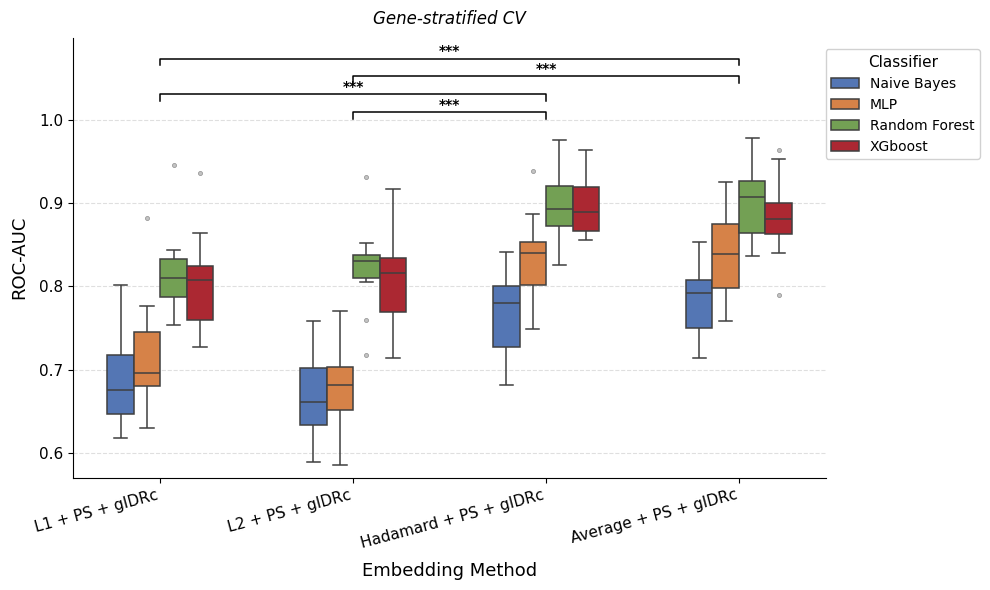

Saved → figure4_roc_auc_gene.png


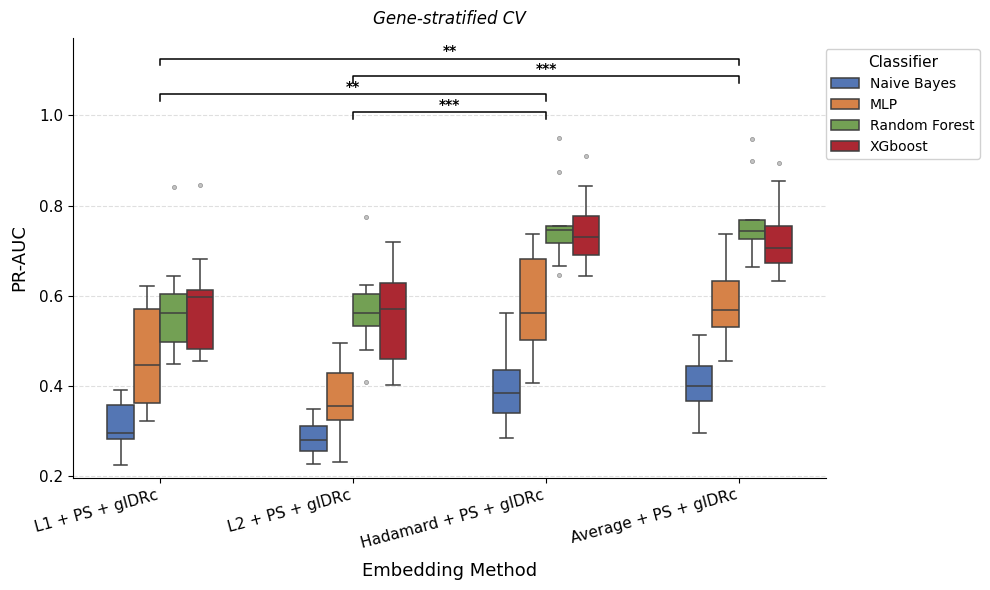

Saved → figure4_pr_auc_gene.png

Kruskal-Wallis [method] roc_auc: H=7.150, p=0.0673
Dunn post hoc saved → dunn_method_roc_random.csv

Kruskal-Wallis [method] pr_auc: H=2.223, p=0.5275
Dunn post hoc saved → dunn_method_pr_random.csv


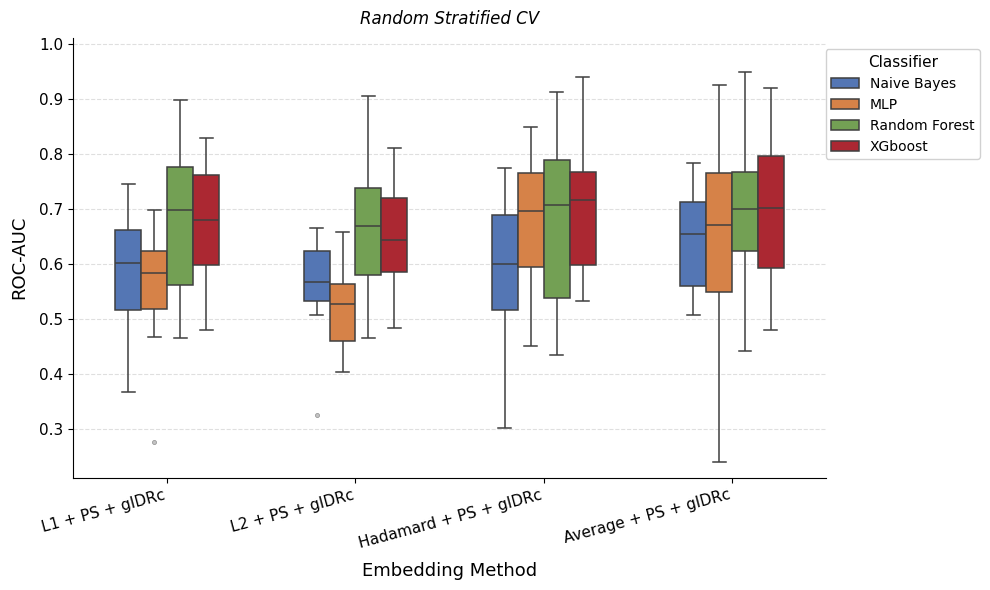

Saved → figure4_roc_auc_random.png


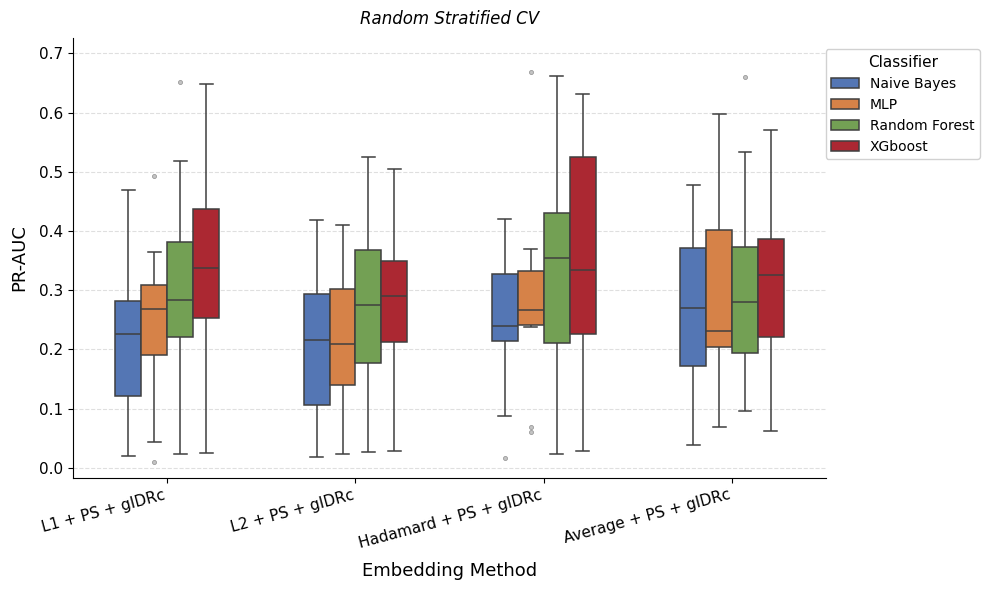

Saved → figure4_pr_auc_random.png


In [32]:
METHOD_ORDER = ['L1 + PS + gIDRc', 'L2 + PS + gIDRc',
                'Hadamard + PS + gIDRc', 'Average + PS + gIDRc']
MODEL_ORDER  = ['Naive Bayes', 'MLP', 'Random Forest', 'XGboost']  # lowercase 'b'
MODEL_COLORS = ['#4472C4', '#ED7D31', '#70AD47', '#C1121F']
MODEL_PALETTE = dict(zip(MODEL_ORDER, MODEL_COLORS))


for cv_type in ['gene', 'random']:
    cv_label = 'Gene-stratified CV' if cv_type == 'gene' else 'Random Stratified CV'
    plot_df  = emd_results_df[emd_results_df['cv_type'] == cv_type].copy()

    if 'auc_pr' in plot_df.columns and 'pr_auc' not in plot_df.columns:
        plot_df = plot_df.rename(columns={'auc_pr': 'pr_auc'})

    avail_methods = [m for m in METHOD_ORDER if m in plot_df['method'].unique()]
    avail_models  = [m for m in MODEL_ORDER  if m in plot_df['model_name'].unique()]

    # Run Kruskal-Wallis + Dunn for both metrics
    _, _, dunn_method_roc = add_kruskal_results(plot_df, 'roc_auc', 'method',
                                                 f'dunn_method_roc_{cv_type}.csv')
    _, _, dunn_method_pr  = add_kruskal_results(plot_df, 'pr_auc',  'method',
                                                 f'dunn_method_pr_{cv_type}.csv')

    for metric, ylabel, dunn_m, fname in [
        ('roc_auc', 'ROC-AUC', dunn_method_roc,
         f'figure4_roc_auc_{cv_type}.png'),
        ('pr_auc',  'PR-AUC',  dunn_method_pr,
         f'figure4_pr_auc_{cv_type}.png'),
    ]:
        # Kruskal-Wallis stats for annotation
        stat_m, p_m = kruskal(*[
            plot_df[plot_df['method'] == m][metric].dropna().values
            for m in avail_methods
        ])
        stat_c, p_c = kruskal(*[
            plot_df[plot_df['model_name'] == m][metric].dropna().values
            for m in avail_models
        ])

        fig, ax = plt.subplots(figsize=(10, 6))

        sns.boxplot(
            data=plot_df,
            x='method', y=metric,
            hue='model_name',
            order=avail_methods,
            hue_order=avail_models,
            palette=MODEL_PALETTE,
            width=0.55,
            linewidth=1.1,
            flierprops=dict(marker='o', markersize=3,
                            markerfacecolor='#888888',
                            markeredgewidth=0.5, alpha=0.5),
            ax=ax,
        )

        # ── Significance brackets between methods ─────────────────────────
        y_top     = plot_df[metric].max()
        y_range   = plot_df[metric].max() - plot_df[metric].min()
        step      = 0.055 * y_range
        brac_base = y_top + 0.06 * y_range
        level     = brac_base

        pairs = list(itertools.combinations(range(len(avail_methods)), 2))
        # Only draw brackets for significant pairs, sorted by span width
        sig_pairs = []
        for (i, j) in pairs:
            m1, m2 = avail_methods[i], avail_methods[j]
            if m1 in dunn_m.index and m2 in dunn_m.columns:
                p_pair = dunn_m.loc[m1, m2]
                if p_pair < 0.05:
                    sig_pairs.append((i, j, p_pair))

        # Sort by span so shorter brackets are lower
        sig_pairs.sort(key=lambda x: x[1] - x[0])

        for (i, j, p_pair) in sig_pairs:
            x1, x2 = i, j
            ax.plot([x1, x1, x2, x2],
                    [level, level + step * 0.35,
                     level + step * 0.35, level],
                    lw=1.1, color='black')
            ax.text((x1 + x2) / 2, level + step * 0.38,
                    sig_label(p_pair),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
            level += step

        # ── KW annotation box ─────────────────────────────────────────────
        #ax.text(0.98, 0.03,
        #        f'KW (method):     H={stat_m:.2f}, p={p_m:.3f}\n'
        #        f'KW (classifier): H={stat_c:.2f}, p={p_c:.3f}',
        #        transform=ax.transAxes,
        #        fontsize=9, va='bottom', ha='right', family='monospace',
        #        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
        #                  alpha=0.85, edgecolor='#bbbbbb'))

        # ── Formatting ────────────────────────────────────────────────────
        ax.set_xlabel('Embedding Method', fontsize=13, labelpad=8)
        ax.set_ylabel(ylabel, fontsize=13, labelpad=8)
        ax.set_xticklabels(avail_methods, rotation=15, ha='right', fontsize=11)
        ax.tick_params(axis='y', labelsize=11)
        ax.set_ylim(
            plot_df[metric].min() - 0.04 * y_range,
            level + step * 0.5,
        )
        ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        sns.despine(ax=ax)

        ax.legend(
            title='Classifier', fontsize=10, title_fontsize=11,
            framealpha=0.9, edgecolor='#cccccc',
            loc='upper left', bbox_to_anchor=(0.99, 0.99),
        )

        plt.title(cv_label, fontsize=12, fontstyle='italic', pad=10)
        plt.tight_layout()
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved → {fname}")

In [ ]:
hpo_configs = [
    (average_X_raw,       y_encoded,      genes,            'default',                       'delta_emb_average'),
    (average_eve_X_raw,   y_encoded,      genes,            'EVE',                           'delta_emb_average'),
    (average_esm_X_raw,   y_encoded,      genes,            'ESM1B',                         'delta_emb_average'),
    (average_am_X_raw,    y_encoded,      genes,            'AlphaMissense',                 'delta_emb_average'),
    (combined_standalone_X, y_combined_sa, genes_combined_sa,'Combined_Standalone_AM_ESM_EVE', None),
    (average_all_X_raw,   y_encoded,      genes,            'IFP_MIDR_All_Three',            'delta_emb_average'),
]

gene_hpo_results = {}
for X, y, g, name, emb_pat in hpo_configs:
    result = train_optimize_xgboost(
        X, y, g, name,
        emb_pattern=emb_pat, target_dim=20,
        split_strategy='random',
    )
    gene_hpo_results[name] = result

# Unpack for downstream use
(xg_best_params,  xg_trial_df,  xg_test_results,  train_val_indices,  test_indices,  xg_test_pred_proba,  xg_test_summary)   = gene_hpo_results['default']
(eve_xg_best_params, eve_xg_trial_df, eve_xg_test_results, eve_train_val_indices, eve_test_indices, eve_test_pred_proba, eve_model_summary) = gene_hpo_results['EVE']
(esm_xg_best_params, esm_xg_trial_df, esm_xg_test_results, esm_train_val_indices, esm_test_indices, esm_test_pred_proba, esm_model_summary) = gene_hpo_results['ESM1B']
(am_xg_best_params,  am_xg_trial_df,  am_xg_test_results,  am_train_val_indices,  am_test_indices,  am_test_pred_proba,  am_summary)        = gene_hpo_results['AlphaMissense']
(combined_sa_best_params, combined_sa_trial_df, combined_sa_test_results, combined_sa_train_idx, combined_sa_test_idx, combined_sa_pred_proba, combined_sa_summary) = gene_hpo_results['Combined_Standalone_AM_ESM_EVE']
(all_xg_best_params, all_xg_trial_df, all_xg_test_results, all_train_val_indices, all_test_indices, all_test_pred_proba, all_summary) = gene_hpo_results['IFP_MIDR_All_Three']


[default | random] Train: 1683 (253 Del / 1430 Neu) | Test: 421 (63 Del / 358 Neu)

[default] Best CV PR-AUC: 0.7414 ± 0.0785
[default | random] Test PR-AUC: 0.7986 | ROC-AUC: 0.9256
[EVE | random] Train: 1683 (253 Del / 1430 Neu) | Test: 421 (63 Del / 358 Neu)

[EVE] Best CV PR-AUC: 0.7879 ± 0.0685
[EVE | random] Test PR-AUC: 0.8986 | ROC-AUC: 0.9682
[ESM1B | random] Train: 1683 (253 Del / 1430 Neu) | Test: 421 (63 Del / 358 Neu)

[ESM1B] Best CV PR-AUC: 0.8313 ± 0.0337
[ESM1B | random] Test PR-AUC: 0.8355 | ROC-AUC: 0.9547
[AlphaMissense | random] Train: 1683 (253 Del / 1430 Neu) | Test: 421 (63 Del / 358 Neu)

[AlphaMissense] Best CV PR-AUC: 0.8544 ± 0.0415
[AlphaMissense | random] Test PR-AUC: 0.9174 | ROC-AUC: 0.9804
[Combined_Standalone_AM_ESM_EVE | random] Train: 1683 (253 Del / 1430 Neu) | Test: 421 (63 Del / 358 Neu)

[Combined_Standalone_AM_ESM_EVE] Best CV PR-AUC: 0.7607 ± 0.0330
[Combined_Standalone_AM_ESM_EVE | random] Test PR-AUC: 0.8305 | ROC-AUC: 0.9391
[IFP_MIDR_All_Th

In [21]:
average_X_raw

,abs_delta_asphericity,abs_delta_radius_of_gyration,abs_delta_end_to_end_distance,abs_delta_scaling_exponent,abs_delta_prefactor,abs_delta_hpi_1.5_frac,abs_delta_hpi_1.5,abs_delta_hpi_2.0_frac,abs_delta_hpi_2.0,abs_delta_hpi_2.5_frac,...,delta_emb_average_value_1014,delta_emb_average_value_1015,delta_emb_average_value_1016,delta_emb_average_value_1017,delta_emb_average_value_1018,delta_emb_average_value_1019,delta_emb_average_value_1020,delta_emb_average_value_1021,delta_emb_average_value_1022,delta_emb_average_value_1023
0,0.000456,0.017019,0.131171,0.000666,0.004899,0.014925,3,0.024876,5,0.0,...,0.045015,-0.014719,-0.040760,0.034745,0.116084,-0.027009,0.042054,0.012633,-0.046882,-0.030794
1,0.000012,0.019358,0.040724,0.000087,0.004465,0.000000,0,0.000000,0,0.0,...,0.043773,-0.011404,-0.040405,0.032851,0.114455,-0.027333,0.041674,0.011481,-0.045557,-0.030270
2,0.002133,0.300385,0.682422,0.002192,0.026192,0.019900,4,0.000000,0,0.0,...,0.046126,-0.013874,-0.038509,0.033463,0.117769,-0.028280,0.042244,0.011543,-0.044995,-0.028253
3,0.000345,0.080911,0.397961,0.000370,0.012559,0.000000,0,0.000000,0,0.0,...,0.043915,-0.012797,-0.040421,0.033368,0.116907,-0.027695,0.040959,0.012436,-0.047011,-0.030524
4,0.000078,0.013206,0.017232,0.000021,0.002676,0.000000,0,0.000000,0,0.0,...,0.043712,-0.012810,-0.039748,0.034275,0.116395,-0.027839,0.041443,0.013072,-0.045798,-0.029682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2099,0.000624,0.022430,0.150302,0.001627,0.163286,0.000000,0,0.000000,0,0.0,...,-0.031959,0.018239,-0.001757,-0.022043,0.081302,-0.043894,0.032415,-0.075918,-0.000056,0.006160
2100,0.001823,0.031386,0.144389,0.000068,0.014254,0.000000,0,0.000000,0,0.0,...,0.037579,-0.010039,-0.009076,0.010813,0.129645,-0.045138,-0.028765,0.023956,0.006797,-0.010213
2101,0.000338,0.012051,0.088943,0.001853,0.041392,0.052632,3,0.000000,0,0.0,...,0.068269,0.018576,-0.034756,0.001638,0.043458,0.004241,0.020838,0.015524,0.023795,-0.006382
2102,0.005744,0.106898,1.553197,0.019815,0.283953,0.000000,0,0.000000,0,0.0,...,0.046431,-0.045318,0.022890,0.036787,0.118049,-0.033110,-0.021304,0.041501,0.016774,0.001469


In [ ]:
random_hpo_results = {}
for X, y, g, name, emb_pat in hpo_configs:
    result = train_optimize_xgboost(
        X, y, g, name,
        emb_pattern=emb_pat, target_dim=20,
        split_strategy='random',
    )
    random_hpo_results[name] = result

# Print comparison table
print("\n" + "="*70)
print(f"{'Model':<35} {'Gene PR-AUC':>12} {'Random PR-AUC':>14}")
print("="*70)
for name, label in [
    ('default',                       'Baseline'),
    ('EVE',                           '+ EVE'),
    ('ESM1B',                         '+ ESM1b'),
    ('AlphaMissense',                 '+ AlphaMissense'),
    ('Combined_Standalone_AM_ESM_EVE','AM+ESM+EVE standalone'),
    ('IFP_MIDR_All_Three',            '+ All Three'),
]:
    gpr = gene_hpo_results[name][2]['pr_auc']
    rpr = random_hpo_results[name][2]['pr_auc']
    print(f"  {label:<33} {gpr:>12.4f} {rpr:>14.4f}")
print("="*70)


In [ ]:
 SAVE_PATH = 'xgboost_results'

def load_hpo_results(eva_type, split_strategy):
    """
    Reconstruct the tuple returned by train_optimize_xgboost from saved files.
    Returns (best_params, trials_df, test_results, train_val_idx, test_idx,
             y_test_pred_proba, cv_summary)
    """
    suffix = f'_{split_strategy}'
    base   = Path(SAVE_PATH) / f'{eva_type}{suffix}'

    # Load JSON files
    with open(f'{base}_best_hyperparameters.json') as f:
        best_params = json.load(f)
    with open(f'{base}_test_results.json') as f:
        test_results = json.load(f)
    with open(f'{base}_comprehensive_results.json') as f:
        cv_summary = json.load(f)

    trials_df = pd.read_json(
        f'{base}_optuna_trials_detailed.json', orient='records'
    )

    # Load saved model and recompute predictions on test set
    # (test indices and pred_proba are not saved — use cv_summary placeholders)
    train_val_idx = []   # not saved — placeholder
    test_idx      = []   # not saved — placeholder
    y_test_pred_proba = np.array([])  # not saved — placeholder

    # Try loading model if needed downstream
    model_path = f'{base}_best_xgboost_model.pkl'
    if Path(model_path).exists():
        print(f"  Model available: {model_path}")

    print(f"  Loaded [{eva_type} | {split_strategy}] "
          f"PR-AUC={test_results['pr_auc']:.4f} "
          f"ROC-AUC={test_results['roc_auc']:.4f}")

    return (best_params, trials_df, test_results,
            train_val_idx, test_idx,
            y_test_pred_proba, cv_summary)


# ── Load all results without re-running ───────────────────────────────────────
model_configs = [
    ('default',                        'Baseline'),
    ('EVE',                            '+ EVE'),
    ('ESM1B',                          '+ ESM1b'),
    ('AlphaMissense',                  '+ AlphaMissense'),
    ('Combined_Standalone_AM_ESM_EVE', 'AM+ESM+EVE standalone'),
    ('IFP_MIDR_All_Three',             '+ All Three'),
]

gene_hpo_results   = {}
random_hpo_results = {}

for eva_type, label in model_configs:
    gene_path   = Path(SAVE_PATH) / f'{eva_type}_gene_test_results.json'
    random_path = Path(SAVE_PATH) / f'{eva_type}_random_test_results.json'

    if gene_path.exists():
        gene_hpo_results[eva_type]   = load_hpo_results(eva_type, 'gene')
    else:
        print(f"  MISSING: {gene_path.name}")

    if random_path.exists():
        random_hpo_results[eva_type] = load_hpo_results(eva_type, 'random')
    else:
        print(f"  MISSING: {random_path.name}")

# ── Unpack for downstream use ─────────────────────────────────────────────────
(xg_best_params,  xg_trial_df,  xg_test_results,  train_val_indices,  test_indices,
 xg_test_pred_proba,  xg_test_summary)   = gene_hpo_results['default']

(eve_xg_best_params, eve_xg_trial_df, eve_xg_test_results, eve_train_val_indices,
 eve_test_indices, eve_test_pred_proba, eve_model_summary) = gene_hpo_results['EVE']

(esm_xg_best_params, esm_xg_trial_df, esm_xg_test_results, esm_train_val_indices,
 esm_test_indices, esm_test_pred_proba, esm_model_summary) = gene_hpo_results['ESM1B']

(am_xg_best_params, am_xg_trial_df, am_xg_test_results, am_train_val_indices,
 am_test_indices, am_test_pred_proba, am_summary) = gene_hpo_results['AlphaMissense']

(combined_sa_best_params, combined_sa_trial_df, combined_sa_test_results,
 combined_sa_train_idx, combined_sa_test_idx, combined_sa_pred_proba,
 combined_sa_summary) = gene_hpo_results['Combined_Standalone_AM_ESM_EVE']

(all_xg_best_params, all_xg_trial_df, all_xg_test_results, all_train_val_indices,
 all_test_indices, all_test_pred_proba, all_summary) = gene_hpo_results['IFP_MIDR_All_Three']

# ── Print comparison table ────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Model':<35} {'Gene PR-AUC':>12} {'Random PR-AUC':>14} {'Gene ROC-AUC':>13} {'Random ROC-AUC':>15}")
print("="*70)
for eva_type, label in model_configs:
    gpr  = gene_hpo_results.get(eva_type,   {2: {'pr_auc':  float('nan')}})[2].get('pr_auc',  float('nan'))
    rpr  = random_hpo_results.get(eva_type, {2: {'pr_auc':  float('nan')}})[2].get('pr_auc',  float('nan'))
    groc = gene_hpo_results.get(eva_type,   {2: {'roc_auc': float('nan')}})[2].get('roc_auc', float('nan'))
    rroc = random_hpo_results.get(eva_type, {2: {'roc_auc': float('nan')}})[2].get('roc_auc', float('nan'))
    print(f"  {label:<33} {gpr:>12.4f} {rpr:>14.4f} {groc:>13.4f} {rroc:>15.4f}")
print("="*70)



In [ ]:
def save_test_predictions(result_tuple, model_name, split_strategy,
                          source_df, outdir='../output/test_predictions'):
    """
    Save hold-out test set predictions with variant metadata to TSV.
    
    Parameters
    ----------
    result_tuple  : output from train_optimize_xgboost
    model_name    : string label for the model
    split_strategy: 'gene' or 'random'
    source_df     : the original delta_emb_df with variant metadata
    outdir        : output directory
    """
    os.makedirs(outdir, exist_ok=True)
    
    (best_params, trials_df, test_results,
     train_val_idx, test_idx,
     y_pred_proba, cv_summary) = result_tuple
    
    if len(test_idx) == 0:
        print(f"  WARNING: no test indices saved for {model_name} — skipping")
        return None
    
    # Pull test variants from source dataframe
    test_meta = source_df.iloc[test_idx].copy().reset_index(drop=True)
    
    # Add predictions
    test_meta['y_pred_proba']  = y_pred_proba
    test_meta['y_pred_label']  = (y_pred_proba >= 0.5).astype(int)
    test_meta['y_true']        = test_meta['Class'].map({'Deleterious': 1, 'Neutral': 0})
    test_meta['correct']       = (test_meta['y_pred_label'] == test_meta['y_true']).astype(int)
    test_meta['model']         = model_name
    test_meta['split']         = split_strategy
    
    # Select output columns
    keep_cols = [
        'GENES', 'mutation', 'UNIPROT_ID', 'CLNHGVS', 'CLNSIG',
        'CLNREVSTAT', 'Class', 'y_true', 'y_pred_proba',
        'y_pred_label', 'correct', 'model', 'split'
    ]
    keep_cols = [c for c in keep_cols if c in test_meta.columns]
    out_df = test_meta[keep_cols].copy()
    
    # Save
    fname = f"{outdir}/{model_name}_{split_strategy}_test_predictions.tsv"
    out_df.to_csv(fname, sep='\t', index=False)
    print(f"  Saved {len(out_df)} variants → {fname}")
    print(f"    PR-AUC: {test_results['pr_auc']:.4f} | "
          f"ROC-AUC: {test_results['roc_auc']:.4f} | "
          f"Accuracy: {test_results['accuracy']:.4f}")
    
    return out_df


# ── Save all gene-stratified test predictions ─────────────────────────────────
print("\nGene-stratified test predictions:")
gene_pred_dfs = {}
for name, label in [
    ('default',                        'IFP-MIDR Baseline'),
    ('EVE',                            'IFP-MIDR + EVE'),
    ('ESM1B',                          'IFP-MIDR + ESM1b'),
    ('AlphaMissense',                  'IFP-MIDR + AlphaMissense'),
    ('Combined_Standalone_AM_ESM_EVE', 'AM + ESM1b + EVE standalone'),
    ('IFP_MIDR_All_Three',             'IFP-MIDR + All Three'),
]:
    df = save_test_predictions(
        gene_hpo_results[name],
        model_name=label,
        split_strategy='gene',
        source_df=delta_emb_df,
    )
    gene_pred_dfs[name] = df

# ── Save all random-stratified test predictions ───────────────────────────────
print("\nRandom-stratified test predictions:")
random_pred_dfs = {}
for name, label in [
    ('default',                        'IFP-MIDR Baseline'),
    ('EVE',                            'IFP-MIDR + EVE'),
    ('ESM1B',                          'IFP-MIDR + ESM1b'),
    ('AlphaMissense',                  'IFP-MIDR + AlphaMissense'),
    ('Combined_Standalone_AM_ESM_EVE', 'AM + ESM1b + EVE standalone'),
    ('IFP_MIDR_All_Three',             'IFP-MIDR + All Three'),
]:
    df = save_test_predictions(
        random_hpo_results[name],
        model_name=label,
        split_strategy='random',
        source_df=delta_emb_df,
    )
    random_pred_dfs[name] = df

# ── Combine all into one master file ─────────────────────────────────────────
all_preds = pd.concat(
    [df for df in list(gene_pred_dfs.values()) + list(random_pred_dfs.values())
     if df is not None],
    ignore_index=True
)
all_preds.to_csv('../output/test_predictions/all_models_test_predictions.tsv',
                 sep='\t', index=False)
print(f"\nMaster file saved → all_models_test_predictions.tsv "
      f"({len(all_preds)} rows)")

# ── Quick summary per model ───────────────────────────────────────────────────
summary = all_preds.groupby(['model', 'split']).apply(lambda g: pd.Series({
    'n_variants':  len(g),
    'n_correct':   g['correct'].sum(),
    'accuracy':    g['correct'].mean().round(4),
    'n_del':       int(g['y_true'].sum()),
    'n_neu':       int((g['y_true'] == 0).sum()),
    'tp':          int(((g['y_true'] == 1) & (g['y_pred_label'] == 1)).sum()),
    'fp':          int(((g['y_true'] == 0) & (g['y_pred_label'] == 1)).sum()),
    'fn':          int(((g['y_true'] == 1) & (g['y_pred_label'] == 0)).sum()),
    'tn':          int(((g['y_true'] == 0) & (g['y_pred_label'] == 0)).sum()),
})).reset_index()

print("\nPREDICTION SUMMARY")
print("="*80)
print(summary.to_string(index=False))
summary.to_csv('../output/test_predictions/prediction_summary.csv', index=False)

In [ ]:
def extract_fold_scores(trials_json_path, method_label, cv_type):
    if not os.path.exists(trials_json_path):
        print(f"  SKIPPING (not found): {trials_json_path}")
        return pd.DataFrame()
    df = pd.read_json(trials_json_path)
    best = df.loc[df['mean_pr_auc'].idxmax()]

    def _parse(x):
        return ast.literal_eval(x) if isinstance(x, str) else list(x)

    return pd.DataFrame({
        'fold':       range(len(_parse(best['pr_auc_scores']))),
        'roc_auc':    _parse(best['roc_auc_scores']),
        'pr_auc':     _parse(best['pr_auc_scores']),
        'accuracy':   _parse(best['accuracy_scores']),
        'method':     method_label,
        'model_name': 'XGBoost/Optuna',
        'cv_type':    cv_type,
    })


# Method label mapping — used for both gene and random
METHOD_LABELS = [
    ('default',                       'Average + PS + gIDRc'),
    ('EVE',                           'XGBoost + EVE + Average + PS + gIDRc'),
    ('ESM1B',                         'XGBoost + ESM1b + Average + PS + gIDRc'),
    ('AlphaMissense',                 'XGBoost + AlphaMissense + Average + PS + gIDRc'),
    ('Combined_Standalone_AM_ESM_EVE','AlphaMissense + ESM1b + EVE (standalone)'),
    ('IFP_MIDR_All_Three',            'IFP-MIDR + AlphaMissense + ESM1b + EVE'),
]

gene_dfs   = [extract_fold_scores(f'xgboost_results/{eva}_gene_optuna_trials_detailed.json',
                                   label, 'gene')
              for eva, label in METHOD_LABELS]

random_dfs = [extract_fold_scores(f'xgboost_results/{eva}_random_optuna_trials_detailed.json',
                                   label, 'gene')
              for eva, label in METHOD_LABELS]

# Standalone predictors from original CSV — run under random CV only
# We also run them under gene-stratified CV using the IFP-MIDR CV framework
noemb_results_df = pd.read_csv('results_noemb_results.initial.multiple_models.csv')
noemb_results_df = (noemb_results_df[noemb_results_df['model'].isin(['AlphaMissense', 'EVE', 'ESM1B'])]
                    [['fold', 'auc', 'pr_auc', 'accuracy', 'method', 'model']]
                    .copy())
noemb_results_df.columns = ['fold', 'roc_auc', 'pr_auc', 'accuracy', 'method', 'model_name']
noemb_results_df['method']  = noemb_results_df['method'].replace({'ESM1B': 'ESM1b'})
noemb_results_df['cv_type'] = 'gene'

# Run standalone predictors through gene-stratified CV for fair comparison
standalone_gene_results = []
for pred_col, method_label in [
    ('AlphaMissense_rankscore', 'AlphaMissense'),
    ('EVE_rankscore',           'EVE'),
    ('ESM1b_rankscore',         'ESM1b'),
]:
    if pred_col not in delta_emb_df.columns:
        continue
    X_sa = delta_emb_df[[pred_col]].apply(pd.to_numeric, errors='coerce').fillna(0)
    df_sa = _run_cv_gene(
        lambda: XGBClassifier(eval_metric='logloss', tree_method='hist',
                              device='cuda', random_state=42),
        X_sa, y_encoded, genes,
        method=method_label, model_name='XGBoost/Optuna',
        n_splits=5, random_state=42, emb_pattern=None,
    )
    # rename auc_pr → pr_auc for consistency
    df_sa = df_sa.rename(columns={'auc_pr': 'pr_auc'})
    standalone_gene_results.append(df_sa)

# Combine everything
all_dfs = (
    [noemb_results_df]
    + standalone_gene_results
    + [d for d in gene_dfs   if not d.empty]
    + [d for d in random_dfs if not d.empty]
)
result_all_df = pd.concat(all_dfs, ignore_index=True)
result_all_df['pr_auc']  = pd.to_numeric(result_all_df['pr_auc'],  errors='coerce')
result_all_df['roc_auc'] = pd.to_numeric(result_all_df['roc_auc'], errors='coerce')
result_all_df = result_all_df.dropna(subset=['pr_auc', 'roc_auc'])
result_all_df.to_csv('../output/all_model_results.csv', index=False)

print("\nMethods per cv_type:")
print(result_all_df.groupby(['cv_type', 'method'])['pr_auc'].agg(['count', 'mean']).round(4))


In [ ]:
METHOD_ORDER = [
    'AlphaMissense',
    'ESM1b',
    'EVE',
    'AlphaMissense + ESM1b + EVE (standalone)',
    'Average + PS + gIDRc',
    'XGBoost + EVE + Average + PS + gIDRc',
    'XGBoost + ESM1b + Average + PS + gIDRc',
    'XGBoost + AlphaMissense + Average + PS + gIDRc',
    'IFP-MIDR + AlphaMissense + ESM1b + EVE',
]

for cv_type in ['gene', 'random']:
    cv_label = 'Gene-stratified' if cv_type == 'gene' else 'Random Stratified'
    plot_df = result_all_df[result_all_df['cv_type'] == cv_type]
    avail   = [m for m in METHOD_ORDER if m in plot_df['method'].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for ax, metric, ylabel in [(axes[0], 'pr_auc', 'PR-AUC'),
                                (axes[1], 'roc_auc', 'ROC-AUC')]:
        sns.boxplot(data=plot_df, x='method', y=metric, order=avail,
                    palette=sns.color_palette('tab10', len(avail)),
                    hue='method', legend=False, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel, fontsize=13)
        ax.axhline(y=y_encoded.mean(), color='gray', linestyle='--',
                   alpha=0.5, label='Random baseline')
        ax.yaxis.grid(True, linestyle='--', alpha=0.4)
        sns.despine(ax=ax)

    plt.suptitle(f'Model Comparison ({cv_label} CV)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figure5_overview_{cv_type}.png', dpi=300, bbox_inches='tight')
    plt.show()



In [ ]:
set(result_all_df.method.tolist())

In [ ]:
PALETTE = {'standalone': '#2D6A4F', 'enhanced': '#C1121F'}

DISPLAY_NAMES = {
    'EVE':           'EVE\n(standalone)',
    'ESM1b':         'ESM1b\n(standalone)',
    'AlphaMissense': 'AlphaMissense\n(standalone)',
    'XGBoost + EVE + Average + PS + gIDRc':           'EVE\nEnhanced',
    'XGBoost + ESM1b + Average + PS + gIDRc':         'ESM1b\nEnhanced',
    'XGBoost + AlphaMissense + Average + PS + gIDRc': 'AlphaMissense\nEnhanced',
    'Average + PS + gIDRc':                           'IFP-MIDR\n(Baseline)',
    'AlphaMissense + ESM1b + EVE (standalone)': 'Combined\n(standalone)',
     'IFP-MIDR + AlphaMissense + ESM1b + EVE': 'Combined\nEnhanced'
}

comparisons_enhanced = [
    ('EVE',           'XGBoost + EVE + Average + PS + gIDRc',           'EVE'),
    ('ESM1b',         'XGBoost + ESM1b + Average + PS + gIDRc',         'ESM1b'),
    ('AlphaMissense', 'XGBoost + AlphaMissense + Average + PS + gIDRc', 'AlphaMissense'),
    ('AlphaMissense + ESM1b + EVE (standalone)', 
     'IFP-MIDR + AlphaMissense + ESM1b + EVE',
     'AlphaMissense + ESM1b + EVE'),   # ← pred_title was missing
]


def _draw_panel(ax, result_df, standalone, enhanced, metric, ylabel,
                cv_type='random', show_ylabel=True, show_title=True, title=''):
    df = result_df[result_df['cv_type'] == cv_type]
    sa_data  = df[df['method'] == standalone][metric].dropna().values
    enh_data = df[df['method'] == enhanced][metric].dropna().values

    if len(sa_data) == 0 or len(enh_data) == 0:
        ax.set_visible(False)
        print(f"  WARNING: no data for '{standalone}' or '{enhanced}' [{cv_type}]")
        return None

    sa_label  = DISPLAY_NAMES.get(standalone, standalone)
    enh_label = DISPLAY_NAMES.get(enhanced,   enhanced)

    box_df = pd.DataFrame({
        metric:  np.concatenate([sa_data, enh_data]),
        'group': [sa_label] * len(sa_data) + [enh_label] * len(enh_data),
    })
    order  = [sa_label, enh_label]
    colors = [PALETTE['standalone'], PALETTE['enhanced']]

    sns.boxplot(data=box_df, x='group', y=metric, order=order,
                palette=dict(zip(order, colors)), hue='group', legend=False,
                width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=2.5,
                                markerfacecolor='#666666', alpha=0.5),
                ax=ax)

    # Mann-Whitney U (raw p-value, no correction)
    _, p = mannwhitneyu(sa_data, enh_data, alternative='two-sided')

    y_max   = box_df[metric].max()
    y_min   = box_df[metric].min()
    y_range = max(y_max - y_min, 0.01)
    brac_y  = y_max + 0.06 * y_range
    brac_h  = 0.05 * y_range

    ax.plot([0, 0, 1, 1],
            [brac_y, brac_y + brac_h, brac_y + brac_h, brac_y],
            lw=1.2, color='black')

    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else f'ns (p={p:.2f})')
    ax.text(0.5, brac_y + brac_h * 1.2, sig,
            ha='center', va='bottom', fontsize=10, fontweight='bold')

    if show_title:
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel if show_ylabel else '', fontsize=11)
    ax.set_ylim(y_min - 0.08 * y_range,
                brac_y + brac_h + 0.20 * y_range)
    ax.set_xticklabels(order, fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

    return {
        'predictor':         standalone,
        'metric':            metric,
        'cv_type':           cv_type,
        'standalone_mean':   float(np.mean(sa_data)),
        'standalone_std':    float(np.std(sa_data)),
        'standalone_median': float(np.median(sa_data)),
        'enhanced_mean':     float(np.mean(enh_data)),
        'enhanced_std':      float(np.std(enh_data)),
        'enhanced_median':   float(np.median(enh_data)),
        'delta_mean':        float(np.mean(enh_data) - np.mean(sa_data)),
        'p_value':           float(p),
        'n_standalone':      len(sa_data),
        'n_enhanced':        len(enh_data),
        'significance':      sig,
    }


def plot_random_pr_roc(result_df, comparisons, outpath_prefix):
    """
    One figure per predictor: 1 row x 2 columns (PR-AUC | ROC-AUC), random CV only.
    Returns a DataFrame of all statistical results.
    """
    all_stats = []

    for standalone, enhanced, pred_title in comparisons:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4.5),
                                 gridspec_kw={'wspace': 0.32})

        for col, (metric, ylabel) in enumerate([('pr_auc',  'PR-AUC'),
                                                 ('roc_auc', 'ROC-AUC')]):
            stats = _draw_panel(
                axes[col], result_df,
                standalone=standalone,
                enhanced=enhanced,
                metric=metric,
                ylabel=ylabel,
                cv_type='random',
                show_ylabel=True,
                show_title=True,
                title=ylabel,
            )
            if stats:
                all_stats.append(stats)

        handles = [
            mpatches.Patch(color=PALETTE['standalone'], label='Standalone predictor'),
            mpatches.Patch(color=PALETTE['enhanced'],   label='IFP-MIDR Enhanced'),
        ]
        fig.legend(handles=handles, fontsize=10, framealpha=0.9,
                   edgecolor='#cccccc', loc='lower center',
                   ncol=2, bbox_to_anchor=(0.5, -0.06))

        #fig.text(0.99, 0.01, 'Mann-Whitney U test',
        #         ha='right', va='bottom', fontsize=7.5,
        #         color='#888888', transform=fig.transFigure)

        fig.suptitle(f'{pred_title} — Random Stratified CV',
                     fontsize=12, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0.08, 1, 1])

        save_path = f"{outpath_prefix}_{pred_title.lower().replace(' ', '_')}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved → {save_path}")

    # Save CSV
    stats_df = pd.DataFrame(all_stats)
    csv_path = f"{outpath_prefix}_statistics.csv"
    stats_df.to_csv(csv_path, index=False)
    print(f"\nStatistics saved → {csv_path}")
    print(stats_df.to_string(index=False))
    return stats_df


# ── Run ───────────────────────────────────────────────────────────────────────
stats_df = plot_random_pr_roc(
    result_all_df,
    comparisons_enhanced,
    outpath_prefix='figure5_random',
)

In [ ]:
def plot_random_panel_figure(result_df, comparisons, metric, ylabel, outpath):
    """
    Single figure with one panel per predictor, all using the same metric.
    Random CV only.
    """
    n_comp = len(comparisons)
    fig, axes = plt.subplots(1, n_comp, figsize=(4.5 * n_comp, 5),
                             sharey=False,
                             gridspec_kw={'wspace': 0.35})
    if n_comp == 1:
        axes = [axes]

    all_stats = []

    for ax, (standalone, enhanced, pred_title) in zip(axes, comparisons):
        stats = _draw_panel(
            ax, result_df,
            standalone=standalone,
            enhanced=enhanced,
            metric=metric,
            ylabel=ylabel,
            cv_type='gene',
            show_ylabel=(ax == axes[0]),
            show_title=True,
            title=pred_title,
        )
        if stats:
            all_stats.append(stats)

    handles = [
        mpatches.Patch(color=PALETTE['standalone'], label='Standalone predictor'),
        mpatches.Patch(color=PALETTE['enhanced'],   label='IFP-MIDR Enhanced'),
    ]
    fig.legend(handles=handles, fontsize=10, framealpha=0.9,
               edgecolor='#cccccc', loc='lower center',
               ncol=2, bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(f'{ylabel} — Random Stratified CV',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {outpath}")
    return all_stats


# ── Run: one figure per metric ────────────────────────────────────────────────
all_stats = []

pr_stats  = plot_random_panel_figure(
    result_all_df,
    comparisons_enhanced,
    metric='pr_auc',
    ylabel='PR-AUC',
    outpath='figure5_random_pr_auc.png',
)
all_stats.extend(pr_stats)

roc_stats = plot_random_panel_figure(
    result_all_df,
    comparisons_enhanced,
    metric='roc_auc',
    ylabel='ROC-AUC',
    outpath='figure5_random_roc_auc.png',
)
all_stats.extend(roc_stats)

# ── Save combined CSV ─────────────────────────────────────────────────────────
stats_df = pd.DataFrame(all_stats)
stats_df.to_csv('figure5_random_statistics.csv', index=False)
print(f"\nStatistics saved → figure5_random_statistics.csv")
print(stats_df.to_string(index=False))

In [ ]:
configs = [
    ('default',                       'gene',   'IFP-MIDR Baseline'),
    ('EVE',                           'gene',   'IFP-MIDR + EVE'),
    ('ESM1B',                         'gene',   'IFP-MIDR + ESM1b'),
    ('AlphaMissense',                 'gene',   'IFP-MIDR + AlphaMissense'),
    ('Combined_Standalone_AM_ESM_EVE','gene',   'AM + ESM1b + EVE (standalone)'),
    ('IFP_MIDR_All_Three',            'gene',   'IFP-MIDR + AM + ESM1b + EVE'),
    ('default',                       'random', 'IFP-MIDR Baseline'),
    ('EVE',                           'random', 'IFP-MIDR + EVE'),
    ('ESM1B',                         'random', 'IFP-MIDR + ESM1b'),
    ('AlphaMissense',                 'random', 'IFP-MIDR + AlphaMissense'),
    ('Combined_Standalone_AM_ESM_EVE','random', 'AM + ESM1b + EVE (standalone)'),
    ('IFP_MIDR_All_Three',            'random', 'IFP-MIDR + AM + ESM1b + EVE'),
]

records = []
for eva_type, split, display_name in configs:
    path = Path(f'xgboost_results/{eva_type}_{split}_test_results.json')
    if not path.exists():
        print(f"  MISSING: {path.name}")
        continue
    with open(path) as f:
        res = json.load(f)
    dist = res.get('test_class_distribution', {})
    n_pos = dist.get('positive', 0)
    n_tot = res.get('n_test_samples', 1)
    records.append({
        'Model':           display_name,
        'Split':           'Gene-stratified' if split == 'gene' else 'Random',
        'N total':         n_tot,
        'N Deleterious':   n_pos,
        'N Neutral':       dist.get('negative', '—'),
        'Positive rate':   round(n_pos / n_tot, 3),
        'ROC-AUC':         round(res['roc_auc'], 4),
        'PR-AUC':          round(res['pr_auc'],  4),
        'PR-AUC/baseline': round(res['pr_auc'] / (n_pos / n_tot), 2),
        'Accuracy':        round(res['accuracy'], 4),
    })

test_df = pd.DataFrame(records)

print("\nHOLD-OUT TEST SET RESULTS")
print("="*100)
print(test_df.to_string(index=False))

# Pivot for side-by-side
MODEL_ORDER = [
    'IFP-MIDR Baseline',
    'AM + ESM1b + EVE (standalone)',
    'IFP-MIDR + EVE',
    'IFP-MIDR + ESM1b',
    'IFP-MIDR + AlphaMissense',
    'IFP-MIDR + AM + ESM1b + EVE',
]
pivot = test_df.pivot(index='Model', columns='Split',
                      values=['PR-AUC', 'ROC-AUC', 'PR-AUC/baseline', 'Accuracy'])
pivot.columns = [f'{m} ({s})' for m, s in pivot.columns]
col_order = ([c for c in pivot.columns if 'PR-AUC (' in c] +
             [c for c in pivot.columns if 'ROC-AUC' in c] +
             [c for c in pivot.columns if 'baseline' in c])
pivot = pivot[[c for c in col_order if c in pivot.columns]]
pivot = pivot.reindex([m for m in MODEL_ORDER if m in pivot.index])

print("\nGENE-STRATIFIED vs RANDOM — SIDE BY SIDE")
print("="*100)
print(pivot.round(4).to_string())

test_df.to_csv('../output/holdout_test_results_flat.gene.csv', index=False)
pivot.to_csv('../output/holdout_test_results_pivot.gene.csv')
print("\nSaved → ../output/holdout_test_results_flat.gene.csv")
print("Saved → ../output/holdout_test_results_pivot.gene.csv")

In [ ]:




def get_star_category(clnrevstat):
    """Map ClinVar review status to star category."""
    if pd.isna(clnrevstat):
        return None
    s = str(clnrevstat).lower()
    if 'reviewed by expert panel' in s:
        return '3 stars\n(Expert panel)'
    elif 'criteria provided, multiple submitters' in s:
        return '2 stars\n(Multiple submitters)'
    elif 'criteria provided, single submitter' in s or 'no assertion criteria' in s:
        return '1 star\n(Single/no criteria)'
    return None


def compute_bootstrap_ci(y_true, y_score, metric_fn, n=1000, seed=42):
    rng   = np.random.default_rng(seed)
    boots = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, yp = y_true[idx], y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        boots.append(metric_fn(yt, yp))
    mean  = float(np.mean(boots))
    ci_lo = float(np.percentile(boots, 2.5))
    ci_hi = float(np.percentile(boots, 97.5))
    return mean, ci_lo, ci_hi


def load_test_predictions(eva_type, split, test_indices, delta_emb_df,
                           y_encoded, pred_proba):
    """
    Build a DataFrame of test variants with true labels,
    predicted probabilities, and ClinVar star category.
    """
    test_df = delta_emb_df.iloc[test_indices].copy().reset_index(drop=True)
    test_df['y_true']    = y_encoded[test_indices]
    test_df['y_pred']    = pred_proba
    test_df['star']      = test_df['CLNREVSTAT'].apply(get_star_category)
    test_df['model']     = eva_type
    test_df['split']     = split
    return test_df


# ── Build test DataFrames for each model ──────────────────────────────────────
# Uses the variables already in memory from HPO runs

model_test_dfs = []

for eva_type, split, test_idx, pred_proba, display_name in [
    ('default',      'random', test_indices_r,          xg_test_pred_proba_r,   'Baseline'),
    ('EVE',          'random', eve_test_indices_r,       eve_test_pred_proba_r,  'IFP-MIDR + EVE'),
    ('ESM1B',        'random', esm_test_indices_r,       esm_test_pred_proba_r,  'IFP-MIDR + ESM1b'),
    ('AlphaMissense','random', am_test_indices_r,        am_test_pred_proba_r,   'IFP-MIDR + AlphaMissense'),
    ('IFP_MIDR_All_Three','random', all_test_indices_r,  all_test_pred_proba_r,  'IFP-MIDR + All Three'),
]:
    df = load_test_predictions(
        display_name, split, test_idx,
        delta_emb_df, y_encoded, pred_proba
    )
    model_test_dfs.append(df)


# ── Compute metrics per model per star category ────────────────────────────────
STAR_ORDER  = [
    '1 star\n(Single/no criteria)',
    '2 stars\n(Multiple submitters)',
    '3 stars\n(Expert panel)',
]
MODEL_ORDER = [
    'Baseline',
    'IFP-MIDR + EVE',
    'IFP-MIDR + ESM1b',
    'IFP-MIDR + AlphaMissense',
    'IFP-MIDR + All Three',
]
MODEL_COLORS = {
    'Baseline':                  '#888888',
    'IFP-MIDR + EVE':            '#2D6A4F',
    'IFP-MIDR + ESM1b':          '#1D3557',
    'IFP-MIDR + AlphaMissense':  '#9B2226',
    'IFP-MIDR + All Three':      '#457B9D',
}

records = []
for df in model_test_dfs:
    model_name = df['model'].iloc[0]
    for star in STAR_ORDER:
        subset = df[df['star'] == star].dropna(subset=['y_true', 'y_pred'])
        if len(subset) < 5 or subset['y_true'].nunique() < 2:
            print(f"  SKIP: {model_name} | {star} — n={len(subset)}, "
                  f"classes={subset['y_true'].nunique()}")
            continue

        y_true = subset['y_true'].values
        y_pred = subset['y_pred'].values
        n_del  = int(y_true.sum())
        n_neu  = int((y_true == 0).sum())

        roc_mean, roc_lo, roc_hi = compute_bootstrap_ci(
            y_true, y_pred, roc_auc_score
        )
        pr_mean, pr_lo, pr_hi = compute_bootstrap_ci(
            y_true, y_pred, average_precision_score
        )

        records.append({
            'model':      model_name,
            'star':       star,
            'n_total':    len(subset),
            'n_del':      n_del,
            'n_neu':      n_neu,
            'roc_auc':    roc_mean,
            'roc_ci_lo':  roc_lo,
            'roc_ci_hi':  roc_hi,
            'pr_auc':     pr_mean,
            'pr_ci_lo':   pr_lo,
            'pr_ci_hi':   pr_hi,
        })

star_df = pd.DataFrame(records)
star_df.to_csv('holdout_star_stratified_metrics.csv', index=False)
print("Saved → holdout_star_stratified_metrics.csv")
print(star_df.to_string(index=False))


# ── Plot function ──────────────────────────────────────────────────────────────
def plot_star_stratified(star_df, metric, ci_lo, ci_hi, ylabel, outpath):
    """
    Grouped bar chart: x = star category, groups = models, y = metric.
    Error bars = 95% bootstrap CI.
    """
    avail_stars  = [s for s in STAR_ORDER  if s in star_df['star'].unique()]
    avail_models = [m for m in MODEL_ORDER if m in star_df['model'].unique()]

    n_stars  = len(avail_stars)
    n_models = len(avail_models)
    bar_w    = 0.15
    x        = np.arange(n_stars)
    offsets  = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * bar_w

    fig, ax = plt.subplots(figsize=(9, 5))

    for offset, model_name in zip(offsets, avail_models):
        color  = MODEL_COLORS.get(model_name, '#333333')
        vals, los, his, ns = [], [], [], []

        for star in avail_stars:
            row = star_df[(star_df['model'] == model_name) &
                          (star_df['star']  == star)]
            if row.empty:
                vals.append(np.nan)
                los.append(np.nan)
                his.append(np.nan)
                ns.append(0)
            else:
                vals.append(row[metric].values[0])
                los.append(row[ci_lo].values[0])
                his.append(row[ci_hi].values[0])
                ns.append(row['n_total'].values[0])

        vals = np.array(vals, dtype=float)
        mask = ~np.isnan(vals)
        xi   = x[mask] + offset

        ax.bar(xi, vals[mask], width=bar_w,
               color=color, label=model_name,
               edgecolor='white', linewidth=0.4, zorder=3)

        yerr_lo = (vals - np.array(los, dtype=float))[mask].clip(min=0)
        yerr_hi = (np.array(his, dtype=float) - vals)[mask].clip(min=0)
        ax.errorbar(xi, vals[mask],
                    yerr=[yerr_lo, yerr_hi],
                    fmt='none', ecolor='#333333',
                    elinewidth=1.0, capsize=3, capthick=1.0, zorder=4)

        # Sample size labels
        for xii, v, n in zip(xi, vals[mask], np.array(ns)[mask]):
            ax.text(xii, 0.01, f'n={n}', ha='center', va='bottom',
                    fontsize=6.5, color='white', fontweight='bold',
                    rotation=90, zorder=5)

    # Random baseline (positive rate in full test set)
    ref = 0.50 if metric == 'roc_auc' else None
    if ref:
        ax.axhline(ref, color='#aaaaaa', linestyle='--',
                   linewidth=0.9, zorder=2, label=f'Random ({ref:.2f})')

    ax.set_xticks(x)
    ax.set_xticklabels(avail_stars, fontsize=10)
    ax.set_xlabel('ClinVar Review Status', fontsize=12, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=12, labelpad=8)
    ax.set_ylim(0, 1.12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=10)
    ax.legend(fontsize=8, framealpha=0.9, edgecolor='#cccccc',
              loc='upper left', ncol=2)
    sns.despine(ax=ax)

    plt.title('Random Stratified CV — Hold-out Test Set', fontsize=11,
              fontstyle='italic', pad=8)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {outpath}")


# ── Generate figures ───────────────────────────────────────────────────────────
plot_star_stratified(
    star_df,
    metric='pr_auc', ci_lo='pr_ci_lo', ci_hi='pr_ci_hi',
    ylabel='PR-AUC',
    outpath='figure_star_stratified_pr_auc.png',
)

plot_star_stratified(
    star_df,
    metric='roc_auc', ci_lo='roc_ci_lo', ci_hi='roc_ci_hi',
    ylabel='ROC-AUC',
    outpath='figure_star_stratified_roc_auc.png',
)

In [ ]:
delta_emb_df.columns

In [ ]:
def summarise_hpo_improvement(trials_json_path, model_name):
    """
    Summarise HPO improvement from trial 0 (random params) to best trial.
    """
    import ast
    df = pd.read_json(trials_json_path)

    # Trial 0 = first random parameter set
    trial0     = df.loc[0]
    best_idx   = df['mean_pr_auc'].idxmax()
    best_trial = df.loc[best_idx]

    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    print(f"Total trials:          {len(df)}")
    print(f"Trial 0  PR-AUC:       {trial0['mean_pr_auc']:.4f}")
    print(f"Median   PR-AUC:       {df['mean_pr_auc'].median():.4f}")
    print(f"Best     PR-AUC:       {best_trial['mean_pr_auc']:.4f} "
          f"(trial {int(best_trial['trial_number'])})")
    print(f"Improvement (0→best):  +{best_trial['mean_pr_auc'] - trial0['mean_pr_auc']:.4f}")
    print(f"Best trial ROC-AUC:    {best_trial['mean_roc_auc']:.4f}")
    print(f"Best hyperparameters:")
    for k, v in best_trial['params'].items():
        print(f"  {k}: {v}")

    return {
        'model':            model_name,
        'n_trials':         len(df),
        'trial0_pr_auc':    float(trial0['mean_pr_auc']),
        'median_pr_auc':    float(df['mean_pr_auc'].median()),
        'best_pr_auc':      float(best_trial['mean_pr_auc']),
        'best_roc_auc':     float(best_trial['mean_roc_auc']),
        'improvement':      float(best_trial['mean_pr_auc'] - trial0['mean_pr_auc']),
        'best_trial_number':int(best_trial['trial_number']),
        'best_params':      best_trial['params'],
    }


# ── Run for all models ────────────────────────────────────────────────────────
hpo_summaries = []
for eva_type, split, display_name in [
    ('default',                       'random', 'IFP-MIDR Baseline'),
    ('EVE',                           'random', 'IFP-MIDR + EVE'),
    ('ESM1B',                         'random', 'IFP-MIDR + ESM1b'),
    ('AlphaMissense',                 'random', 'IFP-MIDR + AlphaMissense'),
    ('Combined_Standalone_AM_ESM_EVE','random', 'AM + ESM1b + EVE (standalone)'),
    ('IFP_MIDR_All_Three',            'random', 'IFP-MIDR + All Three'),
]:
    path = f'xgboost_results/{eva_type}_{split}_optuna_trials_detailed.json'
    if not os.path.exists(path):
        print(f"MISSING: {path}")
        continue
    summary = summarise_hpo_improvement(path, display_name)
    hpo_summaries.append(summary)

hpo_df = pd.DataFrame(hpo_summaries)
hpo_df.to_csv('../output/hpo_improvement_summary.csv', index=False)

print("\nHPO IMPROVEMENT SUMMARY")
print("="*80)
print(hpo_df[['model', 'trial0_pr_auc', 'best_pr_auc',
               'improvement', 'best_roc_auc', 'best_trial_number']].to_string(index=False))